<a href="https://colab.research.google.com/github/gloomy5on/Clasification-of-Trash/blob/main/Project_Plan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA SCIENCE**

# **Menyiapkan semua library yang dibutuhkan**

In [ ]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import pandas as pd
import seaborn as sns
import tensorflow as tf
import cv2
import PIL
from pathlib import Path

### **Library Setup & Functions**

* **`os`** & **`Path`**: Navigasi folder dan manajemen *path* file dataset.
* **`numpy (np)`**: Mengolah gambar sebagai susunan angka (array).
* **`random`**: Mengacak urutan data agar model tidak bias.
* **`matplotlib (plt)`** & **`seaborn (sns)`**: Visualisasi gambar, grafik performa, dan matriks evaluasi.
* **`PIL` & `cv2` (OpenCV)**: *Preprocessing* gambar (buka, resize, manipulasi warna, & rotasi).
* **`pandas (pd)`**: Mengelola tabel data/label dataset.
* **`tensorflow (tf)`**: Framework utama untuk membangun dan melatih model Deep Learning.

---


# **Data Wrangling**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Sampah'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
https://drive.google.com/drive/folders/1SUohhH4xsz3JLsNZDloHzbPd4QeB9swE

Proyek ini menggunakan **Garbage Classification V2**, sebuah dataset komprehensif yang disusun oleh **Suman Kunwar** melalui [Kaggle](https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2) dan beberapa gabungan dataset dari Roboflow. Dataset ini merupakan benchmark citra multi-kelas yang dirancang untuk mendukung otomatisasi pemisahan sampah dan sistem daur ulang berbasis *computer vision*. Dengan cakupan kategori yang luas, data ini digunakan untuk melatih model *deep learning* agar mampu mengklasifikasikan jenis limbah secara akurat, guna menciptakan solusi teknologi yang lebih efisien dalam pengelolaan lingkungan.


Assesing Data

In [ ]:
categories = os.listdir(dataset_path)
stats = []

for category in categories:
    path = os.path.join(dataset_path, category)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        stats.append({'Kategori': category, 'Jumlah': count})

df_stats = pd.DataFrame(stats)

total_images = df_stats['Jumlah'].sum()
print(f"Total seluruh gambar sampah: {total_images}")
print("-" * 30)
print(df_stats.sort_values(by='Jumlah', ascending=False))


Total seluruh gambar sampah: 18226
------------------------------
                 Kategori  Jumlah
14                   Drug    1956
2                 clothes    1892
10                   Food    1791
0                   glass    1736
5                 plastic    1597
9              biological    1479
6                   shoes    1449
1               cardboard    1411
4                   paper    1336
15                   tisu     952
3                   metal     930
7                 battery     756
8                   trash     453
12                   Leaf     196
11  vegetables and fruits     150
13         Pad and Diaper     142


Dataset ini mencakup **12.259 gambar** dengan sebaran yang **tidak seimbang (imbalance)**, di mana kategori *clothes* mendominasi sementara kategori *trash* sangat minim.

---

# **Exploratory Data Analysis (EDA)**

Dalam proses EDA, kami membagi data ke dalam 5 kategori jenis sampah rumah tangga berdasarkan ketentuan Kementerian Lingkungan Hidup dan Kehutanan (KLHK):
* ​Organik: Sampah mudah terurai (sisa makanan, daun).
* ​Anorganik: Sampah plastik, logam, atau kaca yang bisa didaur ulang.
* ​B3 (Bahan Berbahaya dan Beracun): Sampah domestik berbahaya (baterai, obat-obatan).
* ​Kertas: Kategori khusus kertas/karton yang memiliki alur daur ulang tersendiri.
* ​Residu: Sampah yang sulit didaur ulang dan harus langsung dibuang ke TPA (pembalut, popok, tisu bekas).

Data Terbanyak Keseluruhan

In [ ]:
stats = []
for category in os.listdir(dataset_path):
    path = os.path.join(dataset_path, category)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        stats.append({'Kategori': category, 'Jumlah Gambar': count})

df_stats = pd.DataFrame(stats)

total_data = df_stats['Jumlah Gambar'].sum()
paling_banyak = df_stats.loc[df_stats['Jumlah Gambar'].idxmax()]
paling_sedikit = df_stats.loc[df_stats['Jumlah Gambar'].idxmin()]
rata_rata = df_stats['Jumlah Gambar'].mean()

print(f"--- RINGKASAN DATASET ---")
print(f"Total Seluruh Gambar : {total_data}")
print(f"Rata-rata per Kelas  : {rata_rata:.2f}")
print(f"Data Terbanyak       : {paling_banyak['Kategori']} ({paling_banyak['Jumlah Gambar']} gambar)")
print(f"Data Tersedikit      : {paling_sedikit['Kategori']} ({paling_sedikit['Jumlah Gambar']} gambar)")

--- RINGKASAN DATASET ---
Total Seluruh Gambar : 18226
Rata-rata per Kelas  : 1139.12
Data Terbanyak       : Drug (1956 gambar)
Data Tersedikit      : Pad and Diaper (142 gambar)


Dataset ini terdiri dari **12.259 gambar** dengan sebaran yang **tidak seimbang (*imbalance*)**, di mana kategori *clothes* (1.892) sangat mendominasi dibandingkan kategori *trash* (453).

In [ ]:
sampah_mapping = {
    'Food': 'Organik',
    'biological': 'Organik',
    'Leaf': 'Organik',
    'vegetables and fruits': 'Organik',

    'clothes': 'Anorganik',
    'glass': 'Anorganik',
    'plastic': 'Anorganik',
    'shoes': 'Anorganik',
    'metal': 'Anorganik',

    'cardboard': 'Kertas',
    'paper': 'Kertas',

    'Drug': 'B3',
    'battery': 'B3',

    'tisu': 'Residu',
    'trash': 'Residu',
    'Pad and Diaper': 'Residu'
}

df_stats['trash'] = df_stats['Kategori'].map(sampah_mapping)

df_sampah_stats = df_stats.groupby('trash').agg(
    Jumlah=('Jumlah Gambar', 'sum'),
    Jumlah_Jenis=('Kategori', 'nunique')
).reset_index()

df_sampah_stats.columns = ['Kategori Trash', 'Jumlah', 'Jumlah Jenis']

df_sampah_stats = df_sampah_stats.sort_values(by='Jumlah', ascending=False)

print(df_sampah_stats.to_string(index=False))
print("-"*40)
print(f"Total Seluruh Jenis Sampah Asli : {df_sampah_stats['Jumlah Jenis'].sum()}")
print(f"Total Seluruh Gambar Sampah     : {df_sampah_stats['Jumlah'].sum()}")

Kategori Trash  Jumlah  Jumlah Jenis
     Anorganik    7604             5
       Organik    3616             4
        Kertas    2747             2
            B3    2712             2
        Residu    1547             3
----------------------------------------
Total Seluruh Jenis Sampah Asli : 16
Total Seluruh Gambar Sampah     : 18226


Berdasarkan hasil reklasifikasi otomatis tersebut, data menunjukkan adanya ketidakseimbangan kelas (*data imbalance*) yang cukup signifikan, di mana kategori **Anorganik** mendominasi dataset dengan total 7.604 gambar yang mencakup 5 jenis sampah asli, sementara kategori **Residu** memiliki jumlah paling sedikit yaitu 1.547 gambar dari 3 jenis sampah asli. Penentuan 5 kategori utama beserta variasi jumlah jenis sampah di dalamnya ini telah diselaraskan dengan regulasi **Kementerian Lingkungan Hidup dan Kehutanan (KLHK) Republik Indonesia**, sehingga visualisasi dan distribusi data pada tahap EDA ini sudah siap dan valid untuk digunakan sebagai acuan sebelum masuk ke tahap penanganan *imbalance data* dan pemodelan AI.


# **DATA VISUALIZATION**

**Sampel Dataset Sampah**

Found 18225 files belonging to 16 classes.


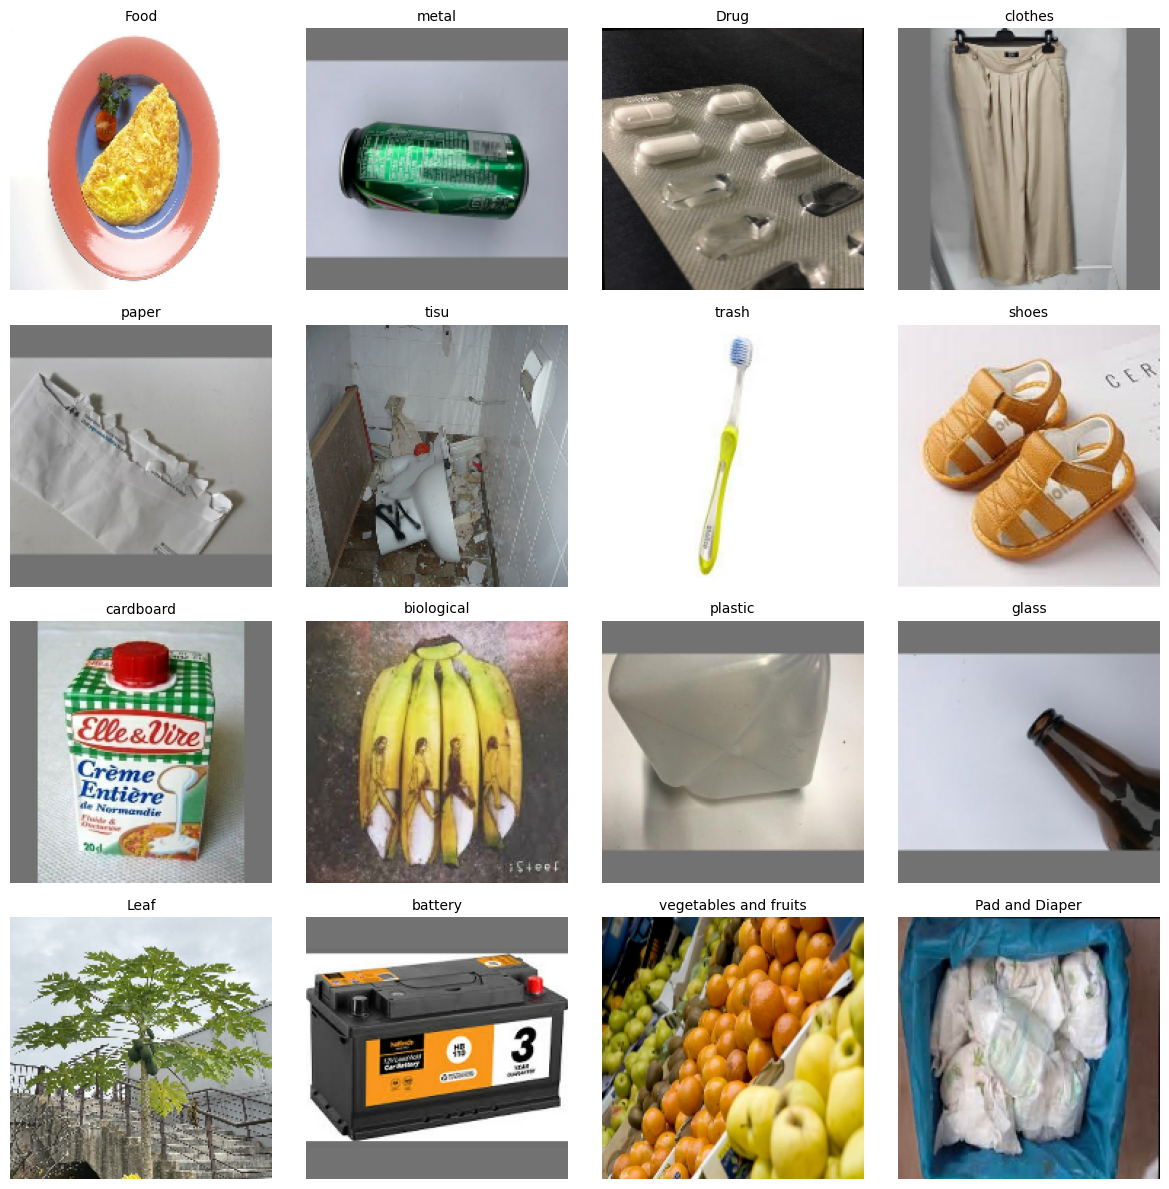

In [ ]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

raw_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    label_mode='int'
)

class_names = raw_data.class_names

shown_classes = set()
j = 0

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

for images, labels in raw_data:
    for i in range(len(images)):
        label_index = labels[i].numpy()
        label_name = class_names[label_index]

        if label_name not in shown_classes:
            img_display = images[i].numpy().astype("uint8")

            axes[j].imshow(img_display)
            axes[j].axis("off")
            axes[j].set_title(label_name, fontsize=10)

            shown_classes.add(label_name)
            j += 1

        if j == 16 or j >= len(class_names):
            break
    if j == 16 or j >= len(class_names):
        break

plt.tight_layout()
plt.show()

**Statistik Dataset Sampah**

Statistik Jumlah Sampah Seluruhnya

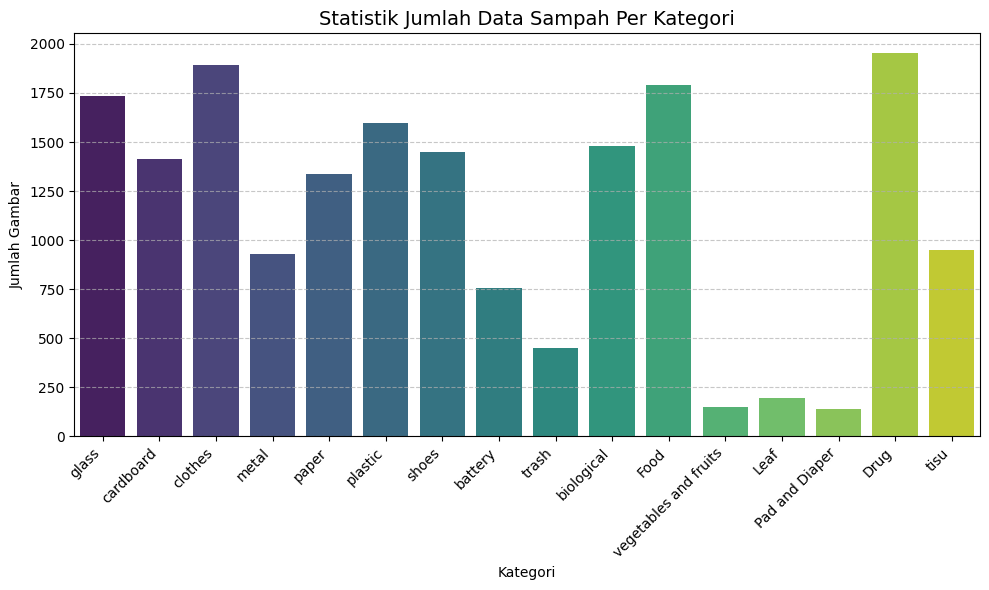

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_stats, x='Kategori', y='Jumlah Gambar', hue='Kategori', palette='viridis', legend=False)
plt.title('Statistik Jumlah Data Sampah Per Kategori', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Berdasarkan grafik batang (bar chart) di atas, kita dapat membedah ketimpangan data secara spesifik ke dalam 5 kelompok besar standar KLHK. Pada kelompok Anorganik (batang ungu-biru tua), sebaran data sebenarnya paling sehat karena kelas clothes (1.892 gambar), glass (1.736 gambar), dan plastic (1.597 gambar) memiliki volume yang seragam, dengan pengecualian pada metal (930 gambar) yang tertinggal sendirian. Sebaliknya, kelompok Organik (batang hijau tua) mengalami ketimpangan internal paling ekstrem; kelas Food (1.791 gambar) dan biological (1.479 gambar) melesat sangat tinggi, sementara kelas Leaf (196 gambar) dan vegetables and fruits (150 gambar) menjadi titik terlemah di seluruh dataset karena tidak menyentuh angka 250 gambar. Kelompok B3 (batang hijau muda) juga tidak seimbang karena sampel Drug (1.956 gambar)—yang sekaligus menjadi bar tertinggi di grafik—memiliki volume hampir tiga kali lipat dari battery (756 gambar). Untuk kelompok Residu (batang hijau zaitun), kelas tisu memimpin dengan 952 gambar, disusul trash (453 gambar) dan Pad and Diaper yang sangat minim (142 gambar). Terakhir, hanya kelompok Kertas (batang ungu-biru sedang) yang menunjukkan distribusi ideal dan seimbang antara cardboard (1.411 gambar) dan paper (1.336 gambar). Secara keseluruhan, dominasi masif dari Drug, clothes, dan Food yang berbanding terbalik dengan minimnya sampel Pad and Diaper serta vegetables and fruits ini menjadi bukti mutlak adanya multi-class imbalance yang wajib ditangani menggunakan teknik penyeimbangan data (re-sampling atau weighted loss) sebelum masuk ke arsitektur pemodelan.

**Jumlah Sampah Perkategori**

Organik

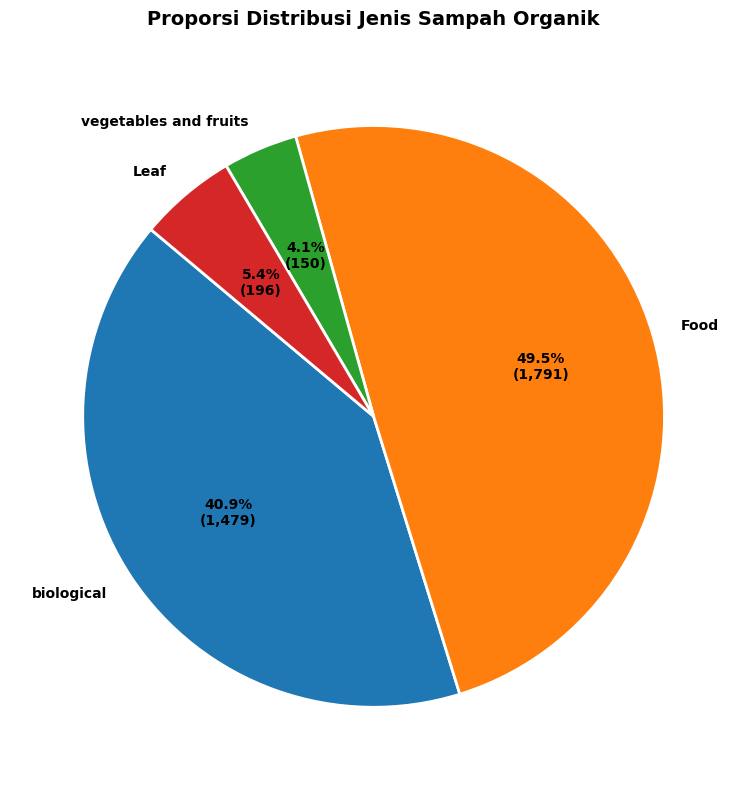

In [ ]:
df_organik = df_stats[df_stats['trash'] == 'Organik']

labels = df_organik['Kategori']
sizes = df_organik['Jumlah Gambar']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=140,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Proporsi Distribusi Jenis Sampah Organik', fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

Berdasarkan grafik pie chart di atas, distribusi data pada kategori Sampah Organik didominasi secara signifikan oleh dua sub-jenis utama, yaitu Food sebesar 49.5% (1.791 gambar) dan biological sebesar 40.9% (1.479 gambar), yang secara akumulatif mencakup lebih dari 90% total sampel dalam kelompok ini. Karakteristik ini menunjukkan bahwa sebagian besar representasi data organik berfokus pada limbah sisa makanan dan bahan biologis. Sebaliknya, sub-jenis Leaf (daun) sebesar 5.4% (196 gambar) dan vegetables and fruits sebesar 4.1% (150 gambar) menjadi minoritas yang sangat kecil. Ketimpangan sebaran data yang cukup ekstrem di dalam kategori organik ini merupakan informasi penting untuk tahap training, karena sistem berisiko lebih sensitif dalam mengenali fitur visual sisa makanan dibandingkan variasi bentuk dedaunan atau buah-buahan akibat keterbatasan sampel gambar pada kedua kelas minoritas tersebut.

Anorganik

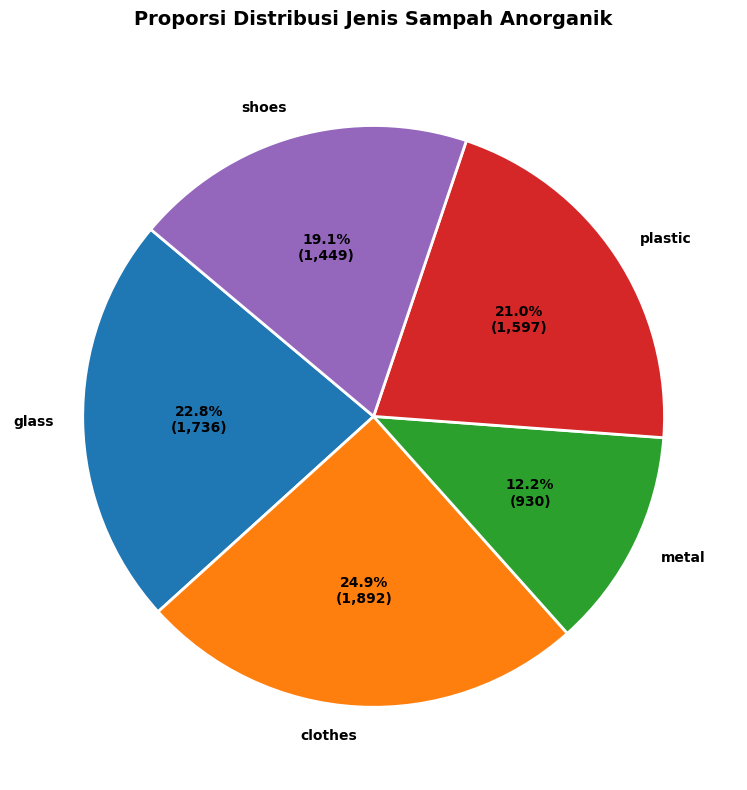

In [ ]:
df_anorganik = df_stats[df_stats['trash'] == 'Anorganik']

labels = df_anorganik['Kategori']
sizes = df_anorganik['Jumlah Gambar']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"

    return my_autopct


plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=140,
    textprops={"fontsize": 10, "weight": "bold"},
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
    },
)

plt.title(
    "Proporsi Distribusi Jenis Sampah Anorganik",
    fontsize=14,
    weight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

Berdasarkan grafik pie chart di atas, distribusi data pada kategori Sampah Anorganik cenderung cukup merata dan tersebar dengan baik di hampir seluruh sub-jenisnya, dengan kontribusi terbesar berasal dari kelas clothes sebesar 24.9% (1.892 gambar), diikuti oleh glass sebesar 22.8% (1.736 gambar), dan plastic sebesar 21.0% (1.597 gambar). Komposisi ini menunjukkan representasi yang kuat untuk variasi objek anorganik berbahan kain, kaca, dan plastik dalam dataset. Di sisi lain, sub-jenis metal (logam) menjadi minoritas di kelompok ini dengan proporsi paling rendah, yaitu hanya 12.2% (930 gambar). Secara keseluruhan, karakteristik sebaran data yang relatif seimbang di kategori anorganik ini sangat menguntungkan untuk tahap training, karena sistem akan mendapatkan variasi sampel yang cukup adil untuk mempelajari fitur-fitur visual unik dari masing-masing material tanpa terlalu didominasi oleh satu sub-jenis tertentu.

B3

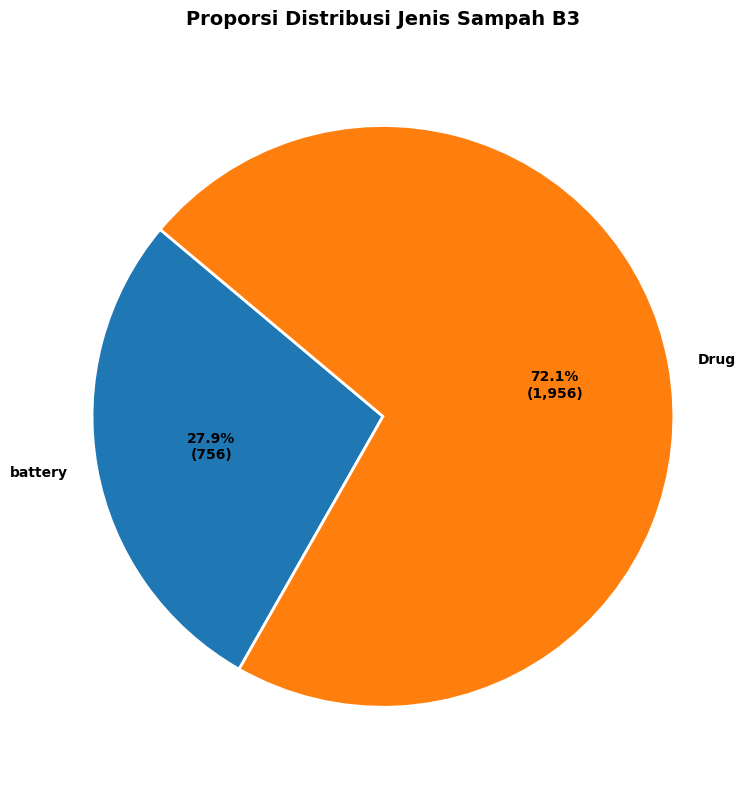

In [ ]:
df_b3 = df_stats[df_stats['trash'] == 'B3']

labels = df_b3['Kategori']
sizes = df_b3['Jumlah Gambar']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"

    return my_autopct


plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=140,
    textprops={"fontsize": 10, "weight": "bold"},
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
    },
)

plt.title(
    "Proporsi Distribusi Jenis Sampah B3",
    fontsize=14,
    weight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

Berdasarkan grafik pie chart di atas, distribusi data pada kategori Sampah B3 menunjukkan dominasi yang sangat kuat oleh satu sub-jenis, yaitu Drug (limbah obat-obatan) dengan proporsi mencapai 72.1% (1.956 gambar) dari total sampel kelompok ini. Sebaliknya, sub-jenis battery (baterai bekas) bertindak sebagai minoritas dengan kontribusi hanya sebesar 27.9% (756 gambar). Ketimpangan jumlah data yang cukup kontras antara kedua sub-jenis ini menjadi catatan penting untuk tahap training, karena model akan memiliki kecenderungan bias yang lebih tinggi dalam mengenali karakteristik visual limbah medis/obat-obatan dibandingkan limbah baterai akibat perbedaan densitas sampel gambar yang diterima selama proses pembelajaran.

Kertas

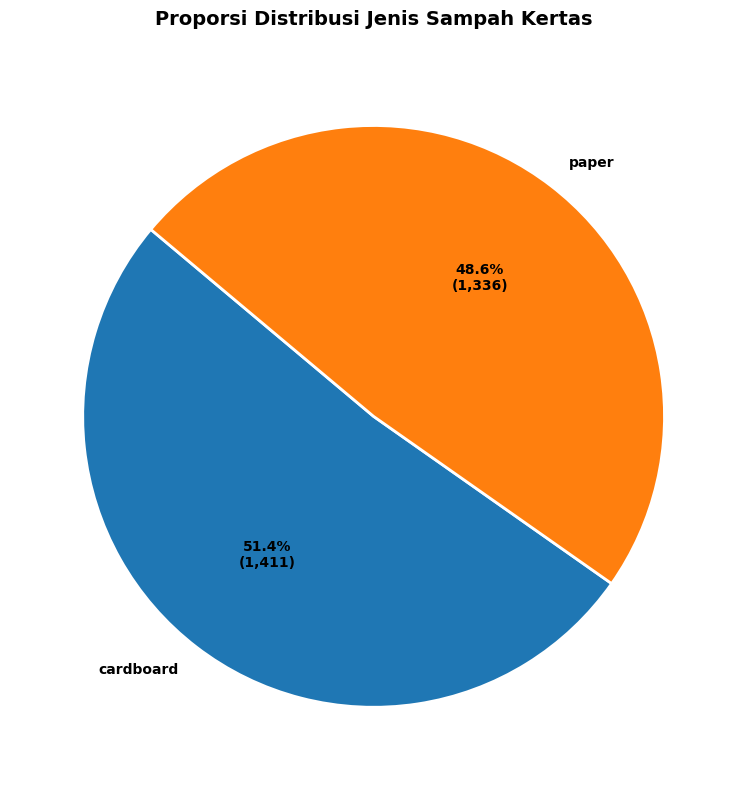

In [ ]:
df_kertas = df_stats[df_stats['trash'] == 'Kertas']

labels = df_kertas['Kategori']
sizes = df_kertas['Jumlah Gambar']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"

    return my_autopct


plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=140,
    textprops={"fontsize": 10, "weight": "bold"},
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
    },
)

plt.title(
    "Proporsi Distribusi Jenis Sampah Kertas",
    fontsize=14,
    weight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

Berdasarkan grafik pie chart di atas, distribusi data pada kategori Sampah Kertas menunjukkan sebaran yang sangat seimbang dan ideal antara kedua sub-jenisnya, di mana cardboard (kardus) memegang porsi sebesar 51.4% (1.411 gambar) dan paper (kertas biasa) sebesar 48.6% (1.336 gambar). Perbedaan jumlah sampel yang sangat tipis di antara kedua kelas ini menandakan tidak adanya dominasi atau ketimpangan data di dalam kelompok sampah kertas. Karakteristik sebaran data yang homogen dan seimbang ini sangat menguntungkan untuk tahap training, karena sistem akan memiliki kemampuan generik yang sama kuatnya dalam mempelajari serta mengenali fitur visual unik dari tekstur kardus maupun lembaran kertas tanpa adanya risiko bias pada salah satu sub-jenis.

Residu

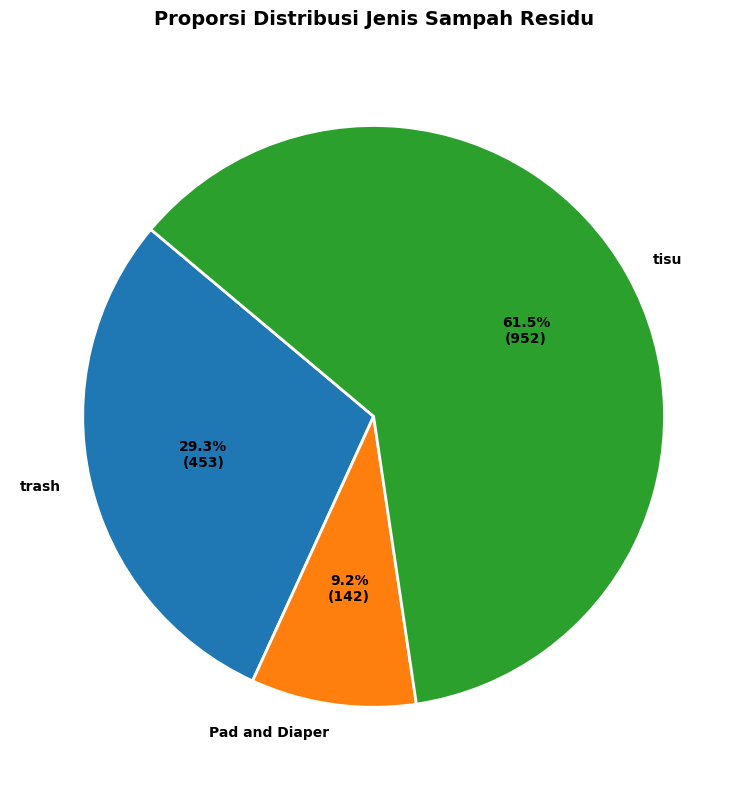

In [ ]:
df_residu = df_stats[df_stats['trash'] == 'Residu']

labels = df_residu['Kategori']
sizes = df_residu['Jumlah Gambar']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"

    return my_autopct


plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=140,
    textprops={"fontsize": 10, "weight": "bold"},
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2,
    },
)

plt.title(
    "Proporsi Distribusi Jenis Sampah Residu",
    fontsize=14,
    weight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

Berdasarkan grafik pie chart di atas, distribusi data pada kategori Sampah Residu didominasi secara signifikan oleh sub-jenis tisu dengan proporsi mencapai 61.5% (952 gambar) dari total sampel kelompok ini. Kontribusi terbesar kedua ditempati oleh sub-jenis trash (sampah umum lainnya) sebesar 29.3% (453 gambar), sedangkan sub-jenis Pad and Diaper (pembalut dan popok) bertindak sebagai minoritas terkecil dengan porsi hanya 9.2% (142 gambar). Ketimpangan sebaran data yang cukup mencolok di dalam kategori residu ini menjadi catatan penting untuk tahap training, karena sistem berisiko jauh lebih adaptif dalam mendeteksi karakteristik visual limbah tisu dibandingkan limbah popok atau pembalut akibat keterbatasan jumlah variasi sampel gambar yang tersedia selama proses pembelajaran.

**Matrix Korelasi Antar Warna**

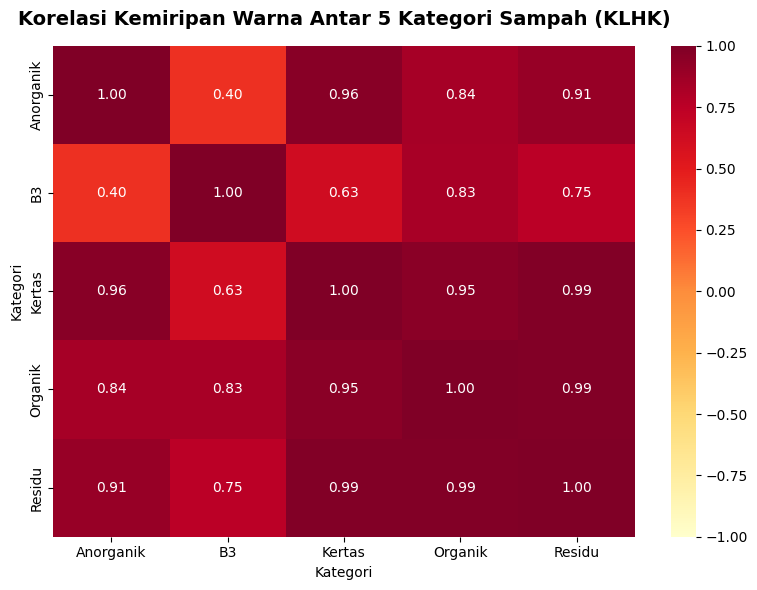

In [ ]:

def extract_color_features(dataset_path):
    all_features = []
    sub_categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for sub_cat in sub_categories:
        if sub_cat not in sampah_mapping:
            continue

        main_category = sampah_mapping[sub_cat]

        cat_path = os.path.join(dataset_path, sub_cat)
        image_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:50]

        for img_name in image_files:
            img = cv2.imread(os.path.join(cat_path, img_name))
            if img is None:
                continue

            avg_color = cv2.mean(img)[:3]

            all_features.append({
                'Kategori': main_category,
                'Red': avg_color[2],
                'Green': avg_color[1],
                'Blue': avg_color[0]
            })

    return pd.DataFrame(all_features)

df_color = extract_color_features(dataset_path)

df_color_grouped = df_color.groupby('Kategori').mean()

corr_color = df_color_grouped.T.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_color, annot=True, cmap='YlOrRd', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Kemiripan Warna Antar 5 Kategori Sampah (KLHK)', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()


Berdasarkan *heatmap* korelasi warna di atas, terlihat nilai korelasi yang sangat tinggi (mendekati 1.00) hampir di seluruh kategori, seperti antara **Kertas, Organik, dan Residu (berkisar antara 0.95 hingga 0.99)**. Hal ini memberikan *insight* krusial bahwa mayoritas gambar dalam dataset ini memiliki karakteristik fitur warna RGB yang sangat mirip atau homogen (kemungkinan besar didominasi oleh latar belakang/background foto yang seragam seperti putih atau abu-abu, atau kondisi pencahayaan yang serupa). Nilai korelasi terendah hanya ditemukan pada hubungan antara **B3 dan Anorganik (0.40)**, yang menandakan kedua kategori ini memiliki kontras warna yang cukup berbeda dibandingkan yang lain. Bagi model *deep learning*, tingginya kemiripan warna antar-kategori ini menjadi alarm bahwa model tidak akan bisa bergantung pada fitur warna saja untuk membedakan jenis sampah, oleh karena itu, model harus dipastikan mampu mengekstraksi fitur tekstur dan bentuk geometri objek secara lebih kuat pada tahap pelatihan nanti agar tidak terjadi salah klasifikasi.
